# Preference for Experimentation
Julian Hsu
2025-May-01

## Problem Setup
We run an experiment where we decide the proportion p of users to assign to treatment each round. Treatment has a negative effect on reward, so the optimal policy is to assign everyone to control — but the agent does not know this upfront.

Both arms have the **same within-arm noise** σ². The pooled outcome variance is:

$$\text{Var}(Y) = \sigma^2 + p(1-p)(\tilde{\mu}_T - \tilde{\mu}_C)^2$$

The between-arm term peaks at p = 0.5 and vanishes at the corners (p → 0 or p → 1).

### Loss function

The agent minimises:

$$L(p) = -\underbrace{\bigl[p\tilde{\mu}_T + (1-p)\tilde{\mu}_C\bigr]}_{\text{expected reward}} + \lambda \underbrace{\bigl[\sigma^2 + p(1-p)(\tilde{\mu}_T - \tilde{\mu}_C)^2\bigr]}_{\text{outcome variance}} - \eta \underbrace{\frac{n \cdot p(1-p)}{\sigma^2}}_{\text{Fisher info for ATE}}$$

- **λ** (variance aversion): penalises outcome variance. High λ → agent prefers corners to eliminate the between-arm term.
- **η** (experimentation incentive): rewards Fisher information. High η → agent prefers balanced allocation to maximise ATE precision.

### Interior vs. corner optimum

The curvature of L in p is:

$$\frac{d^2 L}{dp^2} = -2\lambda(\tilde{\mu}_T - \tilde{\mu}_C)^2 + \frac{2\eta n}{\sigma^2}$$

The sign determines whether corners or an interior allocation wins:

| Condition | Curvature | Optimal p |
|---|---|---|
| λ > λ* = η n / (σ²·gap²) | Negative (concave) | Corner (0 or 1) |
| λ < λ* | Positive (convex) | Interior (~0.5) |

With n = 50, σ = 9, true gap = 3: **λ* = η / 14.58**.

**Initialization:** The first round draws p uniformly at random from the candidate grid, since the agent has no prior data.

**Uncertainty via Thompson sampling:** Each round the agent draws arm means from posteriors N(x̄, σ²/n) rather than using point estimates. Early on the posteriors are wide — the agent cannot immediately identify control as optimal. A high-λ agent commits to whichever corner its current posterior favours; a low-λ agent with sufficient η hedges toward balanced allocation even while still uncertain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## Thompson Sampling for Arm Means

### Why point estimates are not enough

At each round the agent observes the sample mean $\bar{x}_{arm}$ for each arm. This is a noisy estimate of the true mean $\mu_{arm}$. When an arm has been visited infrequently — e.g. only 3 users per round go to treatment — the sample mean can be far from the truth:

$$\text{Var}(\bar{x}) = \frac{\sigma^2}{n} \qquad \Rightarrow \qquad \text{SE}(\bar{x}) = \frac{\sigma}{\sqrt{n}}$$

With $\sigma = 9$ and $n = 15$ (5 rounds at $p = 0.05$): $\text{SE}(\bar{T}) \approx 2.3$. The agent cannot be confident whether treatment or control has the higher expected reward.

Using point estimates ($\bar{T}$, $\bar{C}$) treats the agent as if it *knows* the arm means exactly. That is wrong early on, and it causes the agent to commit to a corner allocation before it has enough evidence.

### The Bayesian posterior

Assume outcomes are normally distributed with **known** within-arm noise $\sigma^2$:

$$Y_i^{(arm)} \sim \mathcal{N}(\mu_{arm},\ \sigma^2)$$

Under a flat (uninformative) prior on $\mu_{arm}$, after observing $n$ outcomes with sample mean $\bar{x}$, the posterior over the true mean is:

$$\mu_{arm} \mid \text{data} \sim \mathcal{N}\!\left(\bar{x},\ \frac{\sigma^2}{n}\right)$$

The posterior mean equals the sample mean $\bar{x}$, and the posterior standard deviation is $\sigma / \sqrt{n}$. This shrinks toward zero as $n$ grows — the agent's belief about the arm mean becomes more precise as more observations arrive.

### Thompson Sampling decision rule

Instead of plugging $\bar{T}$ and $\bar{C}$ directly into the loss, the agent **samples** from the posteriors each round:

$$\tilde{\mu}_T \sim \mathcal{N}\!\left(\bar{T},\ \frac{\sigma_T^2}{n_T}\right), \qquad \tilde{\mu}_C \sim \mathcal{N}\!\left(\bar{C},\ \frac{\sigma_C^2}{n_C}\right)$$

and evaluates the loss using $(\tilde{\mu}_T,\ \tilde{\mu}_C)$ in place of $(\bar{T},\ \bar{C})$.

**What this achieves:**

| Phase | $n$ small | $n$ large |
|---|---|---|
| Posterior width | Wide — $\sigma/\sqrt{n}$ large | Narrow — $\sigma/\sqrt{n} \to 0$ |
| Agent behaviour | Draws may flip the sign of $\tilde{\mu}_T - \tilde{\mu}_C$ → genuine exploration | Draws cluster near true means → exploits the better arm |

The **feedback loop**: the allocation $p$ chosen this round determines $n_T$ and $n_C$ next round, which determines how fast the posteriors tighten. A high-$\lambda$ agent that commits early to treatment will accumulate many treatment observations (tight posterior on $\mu_T \approx -3$) but few control observations (wide posterior on $\mu_C$) — making it slow to discover that control is better.

In [2]:
def loss(reward, variance, info_gain, lambda_weight, eta):
    """L(p) = -reward + lambda*variance - eta*info_gain.

    variance  = sigma^2 + p(1-p)*(mu_T - mu_C)^2  [pooled outcome variance]
    info_gain = p*(1-p)*n/sigma^2                  [Fisher information for ATE]

    Curvature: d^2L/dp^2 = -2*lambda*(mu_T-mu_C)^2 + 2*eta*n/sigma^2
      > 0 (convex, interior optimum) when  eta * n/sigma^2 > lambda * (mu_T-mu_C)^2
      < 0 (concave, corner optimum)   when  lambda > lambda* = eta*n / (sigma^2*(mu_T-mu_C)^2)
    """
    return -reward + lambda_weight * variance - eta * info_gain


def choose_best_allocation(treatment_outcomes, control_outcomes, p_grid, lambda_weight, eta=0.0):
    """Grid-search over p, evaluating loss with Thompson-sampled arm means.

    Uses known sigma^2 throughout (agent knows the noise level from design).
    Thompson sampling draws mu_t, mu_c from N(x_bar, sigma^2/n) posteriors.
    """
    n_t = len(treatment_outcomes)
    n_c = len(control_outcomes)

    if n_t < 1 or n_c < 1:
        return np.random.choice(p_grid)

    T_bar = np.mean(treatment_outcomes)
    C_bar = np.mean(control_outcomes)

    var_known = noise_treat ** 2   # sigma_T = sigma_C = sigma (known, equal)

    # Thompson sampling: posterior N(x_bar, sigma^2/n) -- wide when n small, shrinks with data
    mu_t = np.random.normal(T_bar, noise_treat  / np.sqrt(n_t))
    mu_c = np.random.normal(C_bar, noise_control / np.sqrt(n_c))

    best_loss_val = float('inf')
    best_p = p_grid[len(p_grid) // 2]
    for p in p_grid:
        reward = p * mu_t + (1 - p) * mu_c

        # Pooled outcome variance: sigma^2 (constant) + between-arm term (peaks at p=0.5)
        variance = var_known + p * (1 - p) * (mu_t - mu_c) ** 2

        # Fisher information for ATE: I(p) = n*p*(1-p)/sigma^2 (peaks at p=0.5, zero at corners)
        info_gain = p * (1 - p) * n_per_round / var_known

        cur = loss(reward, variance, info_gain, lambda_weight, eta)
        if cur < best_loss_val:
            best_loss_val = cur
            best_p = p
    return best_p


In [3]:
def outputs(lambda_weight=None, eta=0.0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    allocation_history = []
    cumulative_reward_history = []

    treatment_outcomes = []
    control_outcomes = []
    total_reward = 0

    for t in range(T):
        best_p = choose_best_allocation(
            treatment_outcomes, control_outcomes, p_grid, lambda_weight, eta)

        n_treat   = min(max(int(round(n_per_round * best_p)), 1), n_per_round - 1)
        n_control = n_per_round - n_treat
        allocation_history.append(n_treat / n_per_round)

        treat_outcomes_round = true_effect + np.random.normal(0, noise_treat, n_treat)
        cont_outcomes_round  = np.random.normal(0, noise_control, n_control)

        treatment_outcomes.extend(treat_outcomes_round)
        control_outcomes.extend(cont_outcomes_round)

        total_reward += np.sum(treat_outcomes_round) + np.sum(cont_outcomes_round)
        cumulative_reward_history.append(total_reward)

    return {
        "allocations": allocation_history,
        "cumulative_rewards": cumulative_reward_history,
    }


In [4]:
import pandas as pd

In [5]:
###### Parameters
# The agent NEVER sees these values -- it only observes realized outcomes.
true_effect   = -3     # treatment lowers the outcome; optimal policy is all-control
noise_control = 9      # both arms have equal noise
noise_treat   = 9      # equal noise means only the between-arm term varies with p

n_per_round   = 50     # users assigned each round
T             = 20     # number of rounds
p_grid        = np.linspace(0.05, 0.95, 19)   # candidate treatment proportions


In [6]:
# Threshold for interior optimum: lambda* = eta * n / (sigma^2 * gap^2)
# With n=50, sigma=9 (sigma^2=81), true gap=3 (gap^2=9): lambda* = eta * 50 / (81*9) = eta / 14.58
#
# Sweep 1 (fix eta=15): lambda* ≈ 1.03  →  interior for lambda < 1.03, corners for lambda >= 1.03
# Sweep 2 (fix lambda=0.5): lambda* = 0.5  →  need eta > 0.5 * 14.58 ≈ 7.3 for interior

eta_fixed    = 15.0
lambda_values = [0.0, 0.3, 0.6, 1.5]

lambda_fixed = 0.5
eta_values   = [0.0, 5.0, 15.0, 30.0]

n_runs = 50
seeds  = list(range(n_runs))   # each run uses the same seed across all conditions

results_lambda_sweep = {
    lw: [outputs(lambda_weight=lw, eta=eta_fixed, seed=s) for s in seeds]
    for lw in lambda_values
}
results_eta_sweep = {
    ev: [outputs(lambda_weight=lambda_fixed, eta=ev, seed=s) for s in seeds]
    for ev in eta_values
}

def to_df(results, key):
    return pd.DataFrame([run[key] for run in results])

alloc_lambda  = {lw: to_df(results_lambda_sweep[lw], "allocations")       for lw in lambda_values}
cumrew_lambda = {lw: to_df(results_lambda_sweep[lw], "cumulative_rewards") for lw in lambda_values}
alloc_eta     = {ev: to_df(results_eta_sweep[ev],    "allocations")        for ev in eta_values}
cumrew_eta    = {ev: to_df(results_eta_sweep[ev],    "cumulative_rewards") for ev in eta_values}


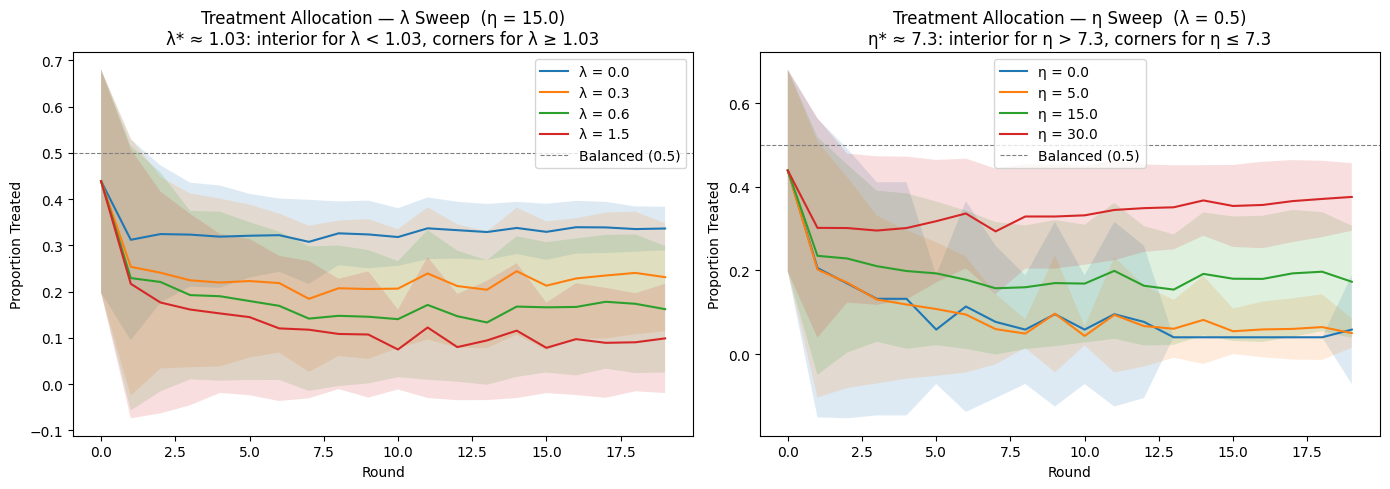

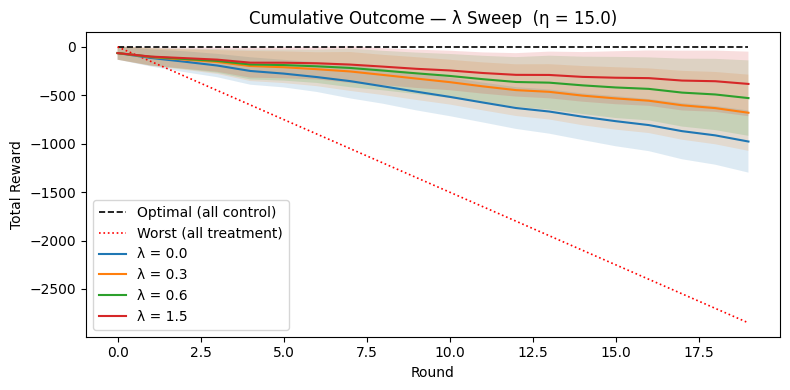

In [7]:
rounds = np.arange(T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: lambda sweep (eta fixed)
ax = axes[0]
for lw in lambda_values:
    m = alloc_lambda[lw].mean()
    s = alloc_lambda[lw].std()
    ax.plot(rounds, m.values, label=f'λ = {lw}')
    ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Balanced (0.5)')
ax.set_title(f'Treatment Allocation — λ Sweep  (η = {eta_fixed})\nλ* ≈ 1.03: interior for λ < 1.03, corners for λ ≥ 1.03')
ax.set_xlabel('Round')
ax.set_ylabel('Proportion Treated')
ax.legend()

# Right: eta sweep (lambda fixed)
ax = axes[1]
for ev in eta_values:
    m = alloc_eta[ev].mean()
    s = alloc_eta[ev].std()
    ax.plot(rounds, m.values, label=f'η = {ev}')
    ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Balanced (0.5)')
ax.set_title(f'Treatment Allocation — η Sweep  (λ = {lambda_fixed})\nη* ≈ 7.3: interior for η > 7.3, corners for η ≤ 7.3')
ax.set_xlabel('Round')
ax.set_ylabel('Proportion Treated')
ax.legend()

plt.tight_layout()
plt.show()

# Cumulative reward: lambda sweep only (shows cost of not experimenting)
fig, ax = plt.subplots(figsize=(8, 4))
optimal_cumrew = np.zeros(T)
worst_cumrew   = n_per_round * rounds * true_effect
ax.plot(optimal_cumrew, linestyle='--', color='black', linewidth=1.2, label='Optimal (all control)')
ax.plot(worst_cumrew,   linestyle=':',  color='red',   linewidth=1.2, label='Worst (all treatment)')
for lw in lambda_values:
    m = cumrew_lambda[lw].mean()
    s = cumrew_lambda[lw].std()
    ax.plot(rounds, m.values, label=f'λ = {lw}')
    ax.fill_between(rounds, (m - s).values, (m + s).values, alpha=0.15)
ax.set_title(f'Cumulative Outcome — λ Sweep  (η = {eta_fixed})')
ax.set_xlabel('Round')
ax.set_ylabel('Total Reward')
ax.legend()
plt.tight_layout()
plt.show()


## FAQ: Why Doesn't a Pure Variance Penalty Work?

With equal known within-arm variance σ² and Thompson-sampled means $(\tilde{\mu}_T, \tilde{\mu}_C)$, the pure variance-penalised loss is:

$$L(p) = -\bigl[p\tilde{\mu}_T + (1-p)\tilde{\mu}_C\bigr] + \lambda\Bigl[\underbrace{\sigma^2}_{\text{constant}} + p(1-p)(\tilde{\mu}_T-\tilde{\mu}_C)^2\Bigr]$$

---

### The loss is concave → corners always win

$$\frac{d^2 L}{dp^2} = -2\lambda(\tilde{\mu}_T-\tilde{\mu}_C)^2 \leq 0$$

The loss is concave in p, so the minimum is always at a corner. Intermediate splits are never optimal, regardless of λ.

---

### λ cancels in the corner comparison

The between-arm term $p(1-p)$ takes the same value at both extreme grid points:

$$p = 0.05\!: \quad 0.05 \times 0.95 = 0.0475 \qquad p = 0.95\!: \quad 0.95 \times 0.05 = 0.0475$$

Therefore:

$$L(0.95) - L(0.05) = -0.9\tilde{\mu}_T + 0.9\tilde{\mu}_C + \lambda\cdot 0 = 0.9(\tilde{\mu}_C - \tilde{\mu}_T)$$

Every λ term cancels. The agent always picks whichever corner matches the current TS draw — **λ has no effect on the allocation, only on the magnitude of the loss**.

---

### Why the Fisher information bonus restores meaningful tradeoffs

Adding the information bonus $-\eta \cdot p(1-p) \cdot n/\sigma^2$ changes the curvature:

$$\frac{d^2 L}{dp^2} = -2\lambda(\tilde{\mu}_T-\tilde{\mu}_C)^2 + \frac{2\eta n}{\sigma^2}$$

When $\eta n/\sigma^2 > \lambda(\tilde{\mu}_T-\tilde{\mu}_C)^2$, the curvature is **positive** (convex) — and an interior p* is now optimal. The η term does not cancel at the corners because both the variance penalty and the information bonus evaluate to the same value 0.0475 there; what changes is whether the interior (p = 0.5, value 0.25) beats either corner:

$$L(0.5) < L(0.05) \iff \underbrace{0.2025\,\eta n/\sigma^2}_{\text{info bonus from experimenting}} > \underbrace{0.45(\tilde{\mu}_C - \tilde{\mu}_T) + 0.2025\,\lambda(\tilde{\mu}_T-\tilde{\mu}_C)^2}_{\text{reward + variance cost of experimenting}}$$

A high-λ agent that is also variance-averse will still prefer corners unless η is large enough to overcome both costs. This creates a genuine tradeoff between exploitation (corners) and experimentation (interior) governed by the ratio λ/η.